ri - псевдослучайные числа в интервале (0,1)

In [ ]:
import math
import numpy as np

a, b, M = 37, 1, 1000
si = []
ui = []
s = 38
for i in range(1, 102):
    u = s/1000
    si.append(s)
    ui.append(u)
    s = (a*s+b)%M

ui.pop(0)
print(ui)
print(len(ui))

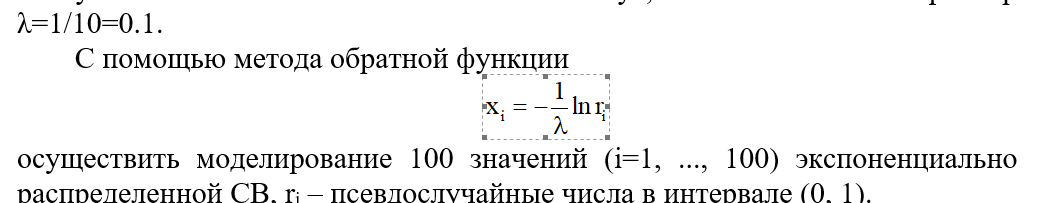

In [ ]:
lambdax = 0.1
xi = []
for i in range(0, 100):
    x = (-1/lambdax)*math.log(ui[i])
    xi.append(x)

print(xi, len(xi))

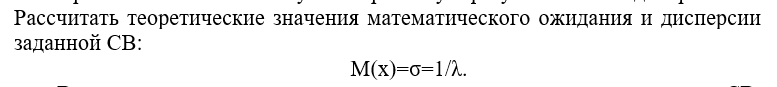

In [ ]:
Mx_theory = D_sqrt_theory = 1/lambdax
print(Mx_theory)

In [ ]:
Mx = sum(xi)*0.01
print(Mx)

In [ ]:
summ = 0
for i in (xi):
    summ += (i - Mx)**2
D = (1/100) * summ
print(D)
D_sqrt = math.sqrt(D)
print(D_sqrt)

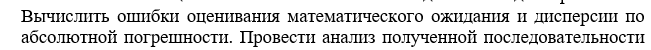

In [ ]:
abs_Mx = abs(Mx - Mx_theory)
abx_D_sqrt = abs(D_sqrt - D_sqrt_theory)
print(abs_Mx, abx_D_sqrt)

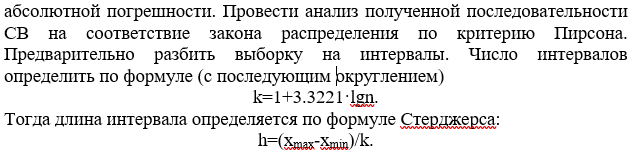

In [ ]:
k = int(1+3.3221*math.log10(100))
h = (max(xi)-min(xi))/k
print(k, h)

In [ ]:
intervals = np.arange(min(xi), max(xi)+h, h)
for i in range(len(intervals)):
    intervals[i] = round(intervals[i],4)
    print("{:.4f}".format(intervals[i]))

ni = [0]*(len(intervals)-1)
for j in range(len(xi)):
    for i in range(len(intervals)-1):
        if intervals[i] <= xi[j] < intervals[i+1]:
            ni[i] += 1

print(ni)
print(sum(ni))

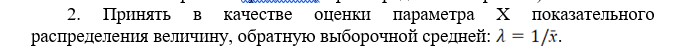

In [ ]:
lambdax = 1/Mx
print(lambdax)

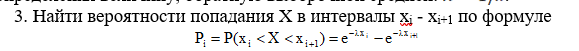

In [ ]:
pi = []
for i in range(0, len(intervals) - 1):
    pi.append(math.e**(-lambdax*intervals[i])-math.e**(-lambdax*intervals[i+1]))
print(pi)
print(sum(pi))

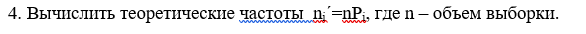

In [ ]:
nis = []
for i in range(0, len(pi)):
    nis.append(100*pi[i])
print(nis)
print(sum(nis))

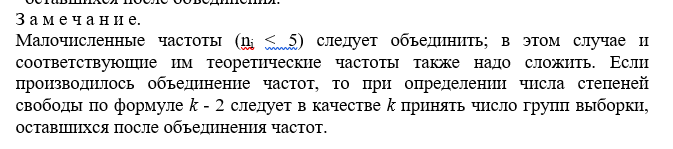

In [ ]:
print(len(ni))
ni[4] += ni[5]
ni[4] += ni[6]
ni.pop(6)
ni.pop(5)
print(ni)
print(len(ni))
nis[4] += nis[5]
nis[4] += nis[6]
nis.pop(6)
nis.pop(5)
print(nis)

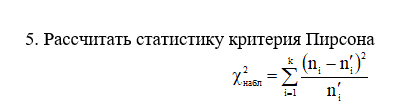

In [ ]:
psumm = 0
for i in range (len(ni)):
    psumm += ((ni[i]-nis[i])**2)/nis[i]

print("Check value ",psumm)

In [ ]:
print(len(ni) - 3)
print("Target value ", 6)

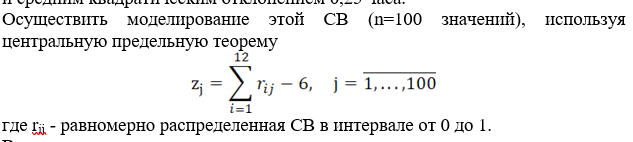

In [ ]:
import numpy
np.random.seed(37)
xi1 = []
for i in range(0, 100):
    r = numpy.random.uniform(0, 1, size=(12))
    r_sum = r.sum()
    z = 3 + 0.25 * (r_sum - 6)
    xi1.append(z)

print(xi1)

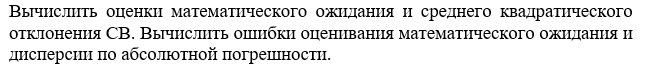

In [ ]:
Mx = sum(xi1)*0.01
print(Mx)

In [ ]:
summ = 0
for i in (xi1):
    summ += (i - Mx)**2
D = (1/100) * summ
D_sqrt = math.sqrt(D)
print(D_sqrt)

In [ ]:
abs_Mx = abs(Mx - 3)
abx_D_sqrt = abs(D_sqrt - 0.25)
print(abs_Mx, abx_D_sqrt)

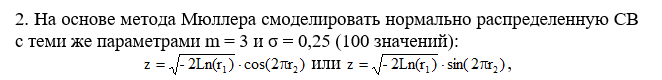

In [ ]:
xi2 = []
np.random.seed(37)
for i in range(0, 100):
    r1 = numpy.random.uniform(0, 1)
    r2 = numpy.random.uniform(0, 1)
    z = math.sqrt(-2*math.log(r1))*math.cos(2*math.pi*r2)
    x = 3 + 0.25 * z
    xi2.append(x)

print(xi2)

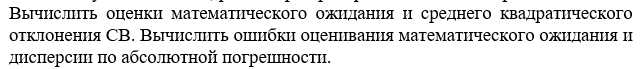

In [ ]:
Mx = sum(xi2)*0.01
print(Mx)

In [ ]:
summ = 0
for i in (xi2):
    summ += (i - Mx)**2
D = (1/100) * summ
D_sqrt = math.sqrt(D)
print(D_sqrt)

In [ ]:
abs_Mx = abs(Mx - 3)
abx_D_sqrt = abs(D_sqrt - 0.25)
print(abs_Mx, abx_D_sqrt)

In [ ]:
k = int(1+3.3221*math.log10(100))
h = (max(xi2)-min(xi2))/k
print(k, h)

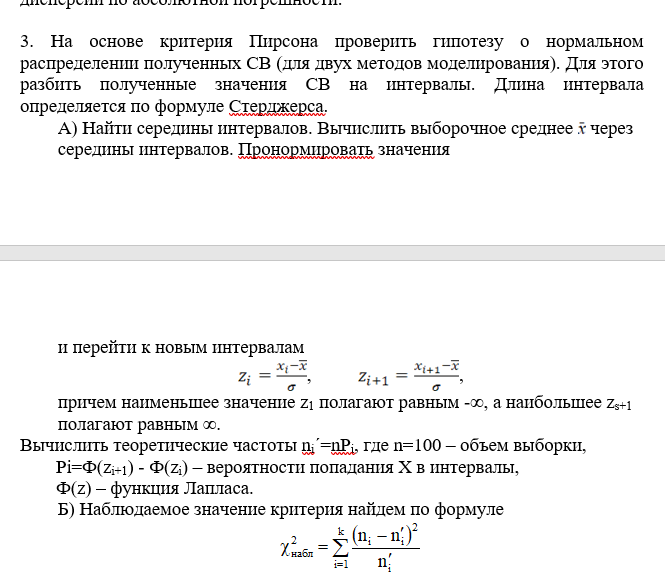

In [ ]:
def merge_frequencies(ni, nis):
    new_ni = list(ni)
    new_nis = list(nis)
    
    i = 0
    while i < len(new_ni):
        if new_ni[i] < 5 and len(new_ni) > 1:
            if i < len(new_ni) - 1:
                new_ni[i] += new_ni[i+1]
                new_nis[i] += new_nis[i+1]
                del new_ni[i+1]
                del new_nis[i+1]
            else:
                new_ni[i-1] += new_ni[i]
                new_nis[i-1] += new_nis[i]
                del new_ni[i]
                del new_nis[i]
                i -= 1
        else:
            i += 1
            
    return new_ni, new_nis

In [ ]:
def pearson_test(data):
    n = len(data)
    k = int(1 + 3.322 * math.log10(n))
    
    x_min = min(data)
    x_max = max(data)
    h = (x_max - x_min) / k
    
    intervals = [x_min + i*h for i in range(k+1)]
    
    ni = [0] * k
    for x in data:
        for i in range(k):
            if intervals[i] <= x < intervals[i+1]:
                ni[i] += 1
                break
            if i == k-1 and x == intervals[i+1]:
                ni[i] += 1
    
    def laplace(x):
        return 0.5 + 0.5 * math.erf(x / math.sqrt(2))
    
    nis = []
    for i in range(k):
        a = intervals[i]
        b = intervals[i+1]
        z_a = (a - 3) / 0.25
        z_b = (b - 3) / 0.25
        p = laplace(z_b) - laplace(z_a)
        nis.append(n * p)
    
    if min(ni) < 5:
        ni, nis = merge_frequencies(ni, nis)
    k = len(ni)

    chi2_obs = 0
    for i in range(k):
        if nis[i] > 0:
            chi2_obs += ((ni[i] - nis[i])**2) / nis[i]
        else:
            pass
            
    df = k - 3
    target_value = 9.5 if df == 4 else 6
    
    print(k, df)
    print(f"Check value {chi2_obs:.4f}")
    print(f"Target value {target_value}")
    print(f"Теоретические частоты n'i: {[round(x, 2) for x in nis]}")
    print(f"Эмпирические частоты ni: {ni}")
    
    return chi2_obs


In [ ]:
chi2_1 = pearson_test(xi1)
chi2_2 = pearson_test(xi2)

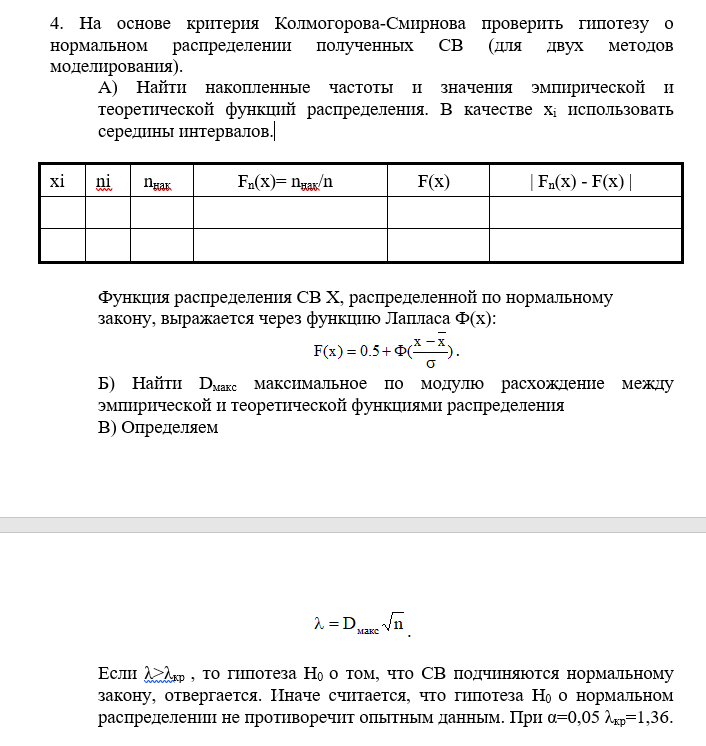

In [ ]:
def kolmogorov_test(data, m_true=3, sigma_true=0.25):
    n = len(data)
    
    k = int(1 + 3.3221 * math.log10(n))
    x_min, x_max = min(data), max(data)
    h = (x_max - x_min) / k
    intervals = [x_min + i * h for i in range(k + 1)]

    ni = [0] * k
    for x in data:
        for i in range(k):
            if intervals[i] <= x < intervals[i + 1]:
                ni[i] += 1
                break
            if i == k - 1 and x == intervals[i + 1]:
                ni[i] += 1
    
    midpoints = [(intervals[i] + intervals[i + 1]) / 2 for i in range(k)]
    n_c = []
    s = 0
    for x in ni:
        s += x
        n_c.append(s)

    Fn = [c / n for c in n_c]

    def laplace(x):
        return 0.5 + 0.5 * math.erf(x / math.sqrt(2))
    
    Ft = [laplace((x - m_true) / sigma_true) for x in midpoints]
    
    diffs = [abs(Fn[i] - Ft[i]) for i in range(k)]
    d_max = max(diffs)
    
    lam = d_max * math.sqrt(n)
    lam_crit = 1.36

    print(f"{'i':>3} {'x_i':>8} {'n_i':>5} {'n_нак':>6} "f"{'F_n(x)':>8} {'F(x)':>8} {'|Fn-F|':>9}")
    for i in range(k):
        print(f"{i+1:>3} {midpoints[i]:>8.4f} {ni[i]:>5} {n_c[i]:>6} "f"{Fn[i]:>8.4f} {Ft[i]:>8.4f} {diffs[i]:>9.4f}")
    
    print(f"\nD_max = {d_max:.4f}")
    print(f"λ = D_max·√n = {lam:.4f}")
    print(f"λ_кр = {lam_crit}")
    if lam > lam_crit:
        print("Гипотеза H0 отвергается")
    else:
        print("Гипотеза H0 принимается")

In [ ]:
kolmogorov_test(xi1)
kolmogorov_test(xi2)